In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/damontoyat/plantclef-species-id/species_ids.csv
/kaggle/input/datasets/damontoyat/plantclef-tokeep/to keep/tile_counts.npy
/kaggle/input/datasets/damontoyat/plantclef-tokeep/to keep/max_scores.npy
/kaggle/input/datasets/damontoyat/plantclef-tokeep/to keep/image_scores.npy
/kaggle/input/datasets/damontoyat/plantclef-tokeep/to keep/tile_metadata.csv
/kaggle/input/datasets/damontoyat/plantclef-tokeep/to keep/image_score_summary.csv
/kaggle/input/datasets/damontoyat/plantclef-tokeep/to keep/mean_scores.npy
/kaggle/input/datasets/damontoyat/plantclef-tokeep/to keep/species_ids_clean.csv
/kaggle/input/datasets/damontoyat/plantclef-tokeep/to keep/tile_topk_predictions.csv
/kaggle/input/datasets/damontoyat/plantclef-tokeep/to keep/run_config.json
/kaggle/input/datasets/damontoyat/plantclef-tokeep/to keep/test_ids.csv
/kaggle/input/datasets/damontoyat/plantclef-tokeep/to keep/generated_submissions_summary.csv
/kaggle/input/datasets/damontoyat/plantclef-tokeep/to keep/subm

# BLOQUE 1 — Imports y CFG central

In [2]:
# ============================================================
# BLOQUE 1 — Imports y CFG central
# ============================================================

import os
import gc
import csv
import json
import random
import warnings
from pathlib import Path
from datetime import datetime

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

In [3]:
class CFG:
    seed = 42
    
    # --------------------------------------------------------
    # Input paths
    # --------------------------------------------------------
    to_keep_dir = Path(
        "/kaggle/input/datasets/damontoyat/plantclef-tokeep/to keep"
    )
    
    previous_submissions_dir = to_keep_dir / "submissions"
    
    # Original files, used only for validation if needed
    train_meta_path = Path(
        "/kaggle/input/datasets/damontoyat/plantclef-metadata/PlantCLEF2024_single_plant_training_metadata.csv"
    )
    
    species_path_original = Path(
        "/kaggle/input/datasets/damontoyat/plantclef-species-id/species_ids.csv"
    )
    
    test_meta_path_original = Path(
        "/kaggle/input/datasets/damontoyat/plantclef-test/PlantCLEF2025_test.csv"
    )
    
    test_images_dir = Path(
        "/kaggle/input/datasets/damontoyat/plantclef-test-images/PlantCLEF2025_test_images"
    )
    
    # --------------------------------------------------------
    # Output paths
    # --------------------------------------------------------
    output_dir = Path("/kaggle/working/postprocessing_to_keep")
    submissions_dir = output_dir / "submissions"
    
    # --------------------------------------------------------
    # Main score files from model 1
    # --------------------------------------------------------
    model1_image_scores_file = "image_scores.npy"
    model1_max_scores_file = "max_scores.npy"
    model1_mean_scores_file = "mean_scores.npy"
    
    test_ids_file = "test_ids.csv"
    species_ids_file = "species_ids_clean.csv"
    image_score_summary_file = "image_score_summary.csv"
    run_config_file = "run_config.json"
    
    # --------------------------------------------------------
    # Post-processing settings
    # --------------------------------------------------------
    use_original_score = True
    
    # Score blends to test from saved max_scores and mean_scores
    score_blends = [
        {"name": "blend_max070_mean030", "max_weight": 0.70, "mean_weight": 0.30},
        {"name": "blend_max060_mean040", "max_weight": 0.60, "mean_weight": 0.40},
        {"name": "blend_max050_mean050", "max_weight": 0.50, "mean_weight": 0.50},
        {"name": "blend_max040_mean060", "max_weight": 0.40, "mean_weight": 0.60},
        {"name": "max_only",              "max_weight": 1.00, "mean_weight": 0.00},
        {"name": "mean_only",             "max_weight": 0.00, "mean_weight": 1.00},
    ]
    
    # Conservative fixed top-k/threshold candidates
    fixed_submission_configs = [
        {"name": "top1_thr000",  "topk": 1,  "threshold": 0.00},
        {"name": "top2_thr000",  "topk": 2,  "threshold": 0.00},
        {"name": "top3_thr000",  "topk": 3,  "threshold": 0.00},
        {"name": "top4_thr000",  "topk": 4,  "threshold": 0.00},
        {"name": "top5_thr000",  "topk": 5,  "threshold": 0.00},
        {"name": "top3_thr002",  "topk": 3,  "threshold": 0.02},
        {"name": "top3_thr003",  "topk": 3,  "threshold": 0.03},
        {"name": "top4_thr002",  "topk": 4,  "threshold": 0.02},
        {"name": "top4_thr003",  "topk": 4,  "threshold": 0.03},
        {"name": "top5_thr002",  "topk": 5,  "threshold": 0.02},
        {"name": "top5_thr003",  "topk": 5,  "threshold": 0.03},
        {"name": "top5_thr004",  "topk": 5,  "threshold": 0.04},
        {"name": "top5_thr005",  "topk": 5,  "threshold": 0.05},
        {"name": "top6_thr003",  "topk": 6,  "threshold": 0.03},
        {"name": "top6_thr004",  "topk": 6,  "threshold": 0.04},
        {"name": "top6_thr005",  "topk": 6,  "threshold": 0.05},
        {"name": "top8_thr004",  "topk": 8,  "threshold": 0.04},
        {"name": "top8_thr005",  "topk": 8,  "threshold": 0.05},
    ]
    
    # Dynamic top-k settings
    dynamic_configs = [
        {
            "name": "dynamic_gap_top8",
            "max_topk": 8,
            "min_topk": 1,
            "score_threshold": 0.00,
            "gap_threshold": 0.15,
        },
        {
            "name": "dynamic_gap_top6",
            "max_topk": 6,
            "min_topk": 1,
            "score_threshold": 0.00,
            "gap_threshold": 0.15,
        },
        {
            "name": "dynamic_gap_top5",
            "max_topk": 5,
            "min_topk": 1,
            "score_threshold": 0.00,
            "gap_threshold": 0.12,
        },
        {
            "name": "dynamic_score_top8_thr003",
            "max_topk": 8,
            "min_topk": 1,
            "score_threshold": 0.03,
            "gap_threshold": None,
        },
        {
            "name": "dynamic_score_top6_thr003",
            "max_topk": 6,
            "min_topk": 1,
            "score_threshold": 0.03,
            "gap_threshold": None,
        },
        {
            "name": "dynamic_score_top5_thr004",
            "max_topk": 5,
            "min_topk": 1,
            "score_threshold": 0.04,
            "gap_threshold": None,
        },
    ]
    
    # --------------------------------------------------------
    # Future ensemble settings
    # Disabled for now.
    # --------------------------------------------------------
    use_model2 = False
    model2_to_keep_dir = Path("/kaggle/input/CHANGE_THIS_WHEN_MODEL2_EXISTS/to_keep_model2")
    
    ensemble_weights = [
        {"name": "ens_m1_070_m2_030", "w1": 0.70, "w2": 0.30},
        {"name": "ens_m1_060_m2_040", "w1": 0.60, "w2": 0.40},
        {"name": "ens_m1_050_m2_050", "w1": 0.50, "w2": 0.50},
    ]

# BLOQUE 2 — Reproducibilidad y carpetas de salida

In [4]:
# ============================================================
# BLOQUE 2 — Reproducibilidad y carpetas de salida
# ============================================================

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)


seed_everything(CFG.seed)

CFG.output_dir.mkdir(parents=True, exist_ok=True)
CFG.submissions_dir.mkdir(parents=True, exist_ok=True)

print("Input to_keep_dir:", CFG.to_keep_dir)
print("Output dir:", CFG.output_dir)
print("Submissions dir:", CFG.submissions_dir)

assert CFG.to_keep_dir.exists(), f"to_keep_dir does not exist: {CFG.to_keep_dir}"

Input to_keep_dir: /kaggle/input/datasets/damontoyat/plantclef-tokeep/to keep
Output dir: /kaggle/working/postprocessing_to_keep
Submissions dir: /kaggle/working/postprocessing_to_keep/submissions


# BLOQUE 3 — Inspeccionar archivos disponibles

In [5]:
# ============================================================
# BLOQUE 3 — Inspeccionar archivos disponibles
# ============================================================

print("Files found in to_keep:")

for p in sorted(CFG.to_keep_dir.rglob("*")):
    if p.is_file():
        size_mb = p.stat().st_size / (1024 ** 2)
        print(f"{size_mb:8.2f} MB | {p}")

Files found in to_keep:
    0.00 MB | /kaggle/input/datasets/damontoyat/plantclef-tokeep/to keep/generated_submissions_summary.csv
    0.39 MB | /kaggle/input/datasets/damontoyat/plantclef-tokeep/to keep/image_score_summary.csv
   62.68 MB | /kaggle/input/datasets/damontoyat/plantclef-tokeep/to keep/image_scores.npy
   62.68 MB | /kaggle/input/datasets/damontoyat/plantclef-tokeep/to keep/max_scores.npy
  125.36 MB | /kaggle/input/datasets/damontoyat/plantclef-tokeep/to keep/mean_scores.npy
    0.00 MB | /kaggle/input/datasets/damontoyat/plantclef-tokeep/to keep/run_config.json
    0.06 MB | /kaggle/input/datasets/damontoyat/plantclef-tokeep/to keep/species_ids_clean.csv
    0.23 MB | /kaggle/input/datasets/damontoyat/plantclef-tokeep/to keep/submissions/submission_top10_thr003.csv
    0.27 MB | /kaggle/input/datasets/damontoyat/plantclef-tokeep/to keep/submissions/submission_top12_thr002.csv
    0.32 MB | /kaggle/input/datasets/damontoyat/plantclef-tokeep/to keep/submissions/submission

# BLOQUE 4 — Cargar scores y metadata del modelo 1

In [6]:
# ============================================================
# BLOQUE 4 — Cargar scores y metadata del modelo 1
# ============================================================

model1_image_scores_path = CFG.to_keep_dir / CFG.model1_image_scores_file
model1_max_scores_path = CFG.to_keep_dir / CFG.model1_max_scores_file
model1_mean_scores_path = CFG.to_keep_dir / CFG.model1_mean_scores_file

test_ids_path = CFG.to_keep_dir / CFG.test_ids_file
species_ids_path = CFG.to_keep_dir / CFG.species_ids_file
image_score_summary_path = CFG.to_keep_dir / CFG.image_score_summary_file
run_config_path = CFG.to_keep_dir / CFG.run_config_file

assert model1_image_scores_path.exists(), model1_image_scores_path
assert model1_max_scores_path.exists(), model1_max_scores_path
assert model1_mean_scores_path.exists(), model1_mean_scores_path
assert test_ids_path.exists(), test_ids_path
assert species_ids_path.exists(), species_ids_path

model1_image_scores = np.load(model1_image_scores_path)
model1_max_scores = np.load(model1_max_scores_path)
model1_mean_scores = np.load(model1_mean_scores_path)

test_ids = pd.read_csv(test_ids_path)
species_ids = pd.read_csv(species_ids_path)

if image_score_summary_path.exists():
    image_score_summary = pd.read_csv(image_score_summary_path)
else:
    image_score_summary = None

if run_config_path.exists():
    with open(run_config_path, "r") as f:
        run_config = json.load(f)
else:
    run_config = None

print("model1_image_scores shape:", model1_image_scores.shape)
print("model1_max_scores shape:", model1_max_scores.shape)
print("model1_mean_scores shape:", model1_mean_scores.shape)
print("test_ids shape:", test_ids.shape)
print("species_ids shape:", species_ids.shape)

display(test_ids.head())
display(species_ids.head())

if image_score_summary is not None:
    display(image_score_summary.head())

if run_config is not None:
    print("Previous run config keys:")
    print(list(run_config.keys()))

model1_image_scores shape: (2105, 7806)
model1_max_scores shape: (2105, 7806)
model1_mean_scores shape: (2105, 7806)
test_ids shape: (2105, 2)
species_ids shape: (7806, 1)


,quadrat_id,image_path
0,CBN-PdlC-E3-20130723,/kaggle/input/datasets/damontoyat/plantclef-te...
1,CBN-PdlC-E2-20130723,/kaggle/input/datasets/damontoyat/plantclef-te...
2,CBN-PdlC-E5-20130723,/kaggle/input/datasets/damontoyat/plantclef-te...
3,CBN-PdlC-E6-20130723,/kaggle/input/datasets/damontoyat/plantclef-te...
4,CBN-PdlC-E1-20130723,/kaggle/input/datasets/damontoyat/plantclef-te...


,species_id
0,1355868
1,1355869
2,1355870
3,1355871
4,1355872


,quadrat_id,image_path,tile_count,max_score,mean_score,mean_top5_score,mean_top10_score,n_species_above_001,n_species_above_002,n_species_above_003,n_species_above_005,n_species_above_010
0,CBN-PdlC-E3-20130723,/kaggle/input/datasets/damontoyat/plantclef-te...,26,0.632815,0.000596,0.308872,0.176948,57,31,18,5,3
1,CBN-PdlC-E2-20130723,/kaggle/input/datasets/damontoyat/plantclef-te...,26,0.175946,0.000592,0.129137,0.103062,61,39,26,18,3
2,CBN-PdlC-E5-20130723,/kaggle/input/datasets/damontoyat/plantclef-te...,26,0.281517,0.000809,0.206270,0.147369,98,48,28,17,6
3,CBN-PdlC-E6-20130723,/kaggle/input/datasets/damontoyat/plantclef-te...,26,0.167885,0.000638,0.136171,0.102499,74,41,29,12,5
4,CBN-PdlC-E1-20130723,/kaggle/input/datasets/damontoyat/plantclef-te...,26,0.431158,0.000711,0.287678,0.187621,77,39,23,13,5


Previous run config keys:
['run_datetime', 'seed', 'device', 'test_meta_path', 'species_path', 'test_images_dir', 'output_dir', 'timm_model_name', 'num_classes', 'image_size', 'activation', 'tile_mode', 'grid_size', 'include_full_image', 'border_crop_pct', 'batch_size', 'num_workers', 'use_amp', 'aggregation', 'max_weight', 'mean_weight', 'tile_topk_to_save', 'submission_configs', 'debug', 'debug_n_images']


# BLOQUE 5 — Validaciones de consistencia

In [7]:
# ============================================================
# BLOQUE 5 — Validaciones de consistencia
# ============================================================

assert "quadrat_id" in test_ids.columns
assert "species_id" in species_ids.columns

test_ids["quadrat_id"] = test_ids["quadrat_id"].astype(str)
species_ids["species_id"] = species_ids["species_id"].astype(str)

n_images = len(test_ids)
n_species = len(species_ids)

assert model1_image_scores.shape == (n_images, n_species)
assert model1_max_scores.shape == (n_images, n_species)
assert model1_mean_scores.shape == (n_images, n_species)

assert test_ids["quadrat_id"].nunique() == n_images
assert species_ids["species_id"].nunique() == n_species

species_values = species_ids["species_id"].values
quadrat_values = test_ids["quadrat_id"].values

print("Consistency checks passed.")
print("n_images:", n_images)
print("n_species:", n_species)

Consistency checks passed.
n_images: 2105
n_species: 7806


# BLOQUE 6 — Cargar metadata original de test para análisis de grupos

In [8]:
# ============================================================
# BLOQUE 6 — Cargar metadata original de test para análisis de grupos
# ============================================================

test_meta = pd.read_csv(CFG.test_meta_path_original, sep=";", low_memory=False)

test_meta["quadrat_id"] = test_meta["quadrat_id"].astype(str)
test_meta["date"] = pd.to_datetime(test_meta["date"], errors="coerce")

split_ids = test_meta["quadrat_id"].str.split("-")

test_meta["id_prefix_1"] = split_ids.str[:1].str.join("-")
test_meta["id_prefix_2"] = split_ids.str[:2].str.join("-")
test_meta["id_prefix_3"] = split_ids.str[:3].str.join("-")

test_meta["id_without_date"] = test_meta["quadrat_id"].str.replace(
    r"-\d{8}$", "", regex=True
)

test_meta["transect_guess"] = test_meta["id_without_date"].str.replace(
    r"\d+$", "", regex=True
)

# Preserve the exact order used by the scores
test_meta_ordered = test_ids[["quadrat_id"]].merge(
    test_meta,
    on="quadrat_id",
    how="left"
)

assert len(test_meta_ordered) == len(test_ids)
assert test_meta_ordered["quadrat_id"].tolist() == test_ids["quadrat_id"].tolist()

display(test_meta_ordered.head())

for col in ["id_prefix_1", "id_prefix_2", "id_prefix_3", "transect_guess"]:
    print("=" * 80)
    print(col)
    display(test_meta_ordered[col].value_counts().head(20).to_frame("n_quadrats"))

,quadrat_id,author,date,license,id_prefix_1,id_prefix_2,id_prefix_3,id_without_date,transect_guess
0,CBN-PdlC-E3-20130723,Olivier Argagnon,2013-07-23,cc-by-sa,CBN,CBN-PdlC,CBN-PdlC-E3,CBN-PdlC-E3,CBN-PdlC-E
1,CBN-PdlC-E2-20130723,Olivier Argagnon,2013-07-23,cc-by-sa,CBN,CBN-PdlC,CBN-PdlC-E2,CBN-PdlC-E2,CBN-PdlC-E
2,CBN-PdlC-E5-20130723,Olivier Argagnon,2013-07-23,cc-by-sa,CBN,CBN-PdlC,CBN-PdlC-E5,CBN-PdlC-E5,CBN-PdlC-E
3,CBN-PdlC-E6-20130723,Olivier Argagnon,2013-07-23,cc-by-sa,CBN,CBN-PdlC,CBN-PdlC-E6,CBN-PdlC-E6,CBN-PdlC-E
4,CBN-PdlC-E1-20130723,Olivier Argagnon,2013-07-23,cc-by-sa,CBN,CBN-PdlC,CBN-PdlC-E1,CBN-PdlC-E1,CBN-PdlC-E


id_prefix_1


,n_quadrats
id_prefix_1,
CBN,1476
LISAH,208
GUARDEN,201
RNNB,141
OPTMix,78
2024,1


id_prefix_2


,n_quadrats
id_prefix_2,
CBN-PdlC,816
CBN-Pla,628
GUARDEN-CBNMed,165
LISAH-BOU,82
LISAH-BVD,76
GUARDEN-AMB,36
LISAH-PEC,35
CBN-can,30
RNNB-3,21


id_prefix_3


,n_quadrats
id_prefix_3,
LISAH-BOU-0,82
LISAH-BVD-0,76
CBN-PdlC-F3,26
CBN-PdlC-B5,25
CBN-PdlC-F1,25
CBN-PdlC-F4,25
CBN-PdlC-E1,25
CBN-PdlC-E3,25
CBN-PdlC-B2,24


transect_guess


,n_quadrats
transect_guess,
CBN-PdlC-F,147
CBN-PdlC-E,144
CBN-PdlC-B,142
CBN-PdlC-D,129
CBN-PdlC-C,129
CBN-PdlC-A,125
CBN-Pla-A,113
CBN-Pla-B,112
CBN-Pla-E,103


# BLOQUE 7 — Diagnóstico de scores del modelo 1

In [9]:
# ============================================================
# BLOQUE 7 — Diagnóstico de scores del modelo 1
# ============================================================

def describe_score_matrix(scores, name):
    print("=" * 100)
    print(name)
    print("shape:", scores.shape)
    print("min:", float(scores.min()))
    print("max:", float(scores.max()))
    print("mean:", float(scores.mean()))
    
    max_per_image = scores.max(axis=1)
    
    print("\nMax score per image:")
    display(pd.Series(max_per_image).describe().to_frame("max_score"))
    
    for thr in [0.001, 0.003, 0.005, 0.01, 0.02, 0.03, 0.04, 0.05, 0.08, 0.10]:
        n_above = (scores >= thr).sum(axis=1)
        print(f"Threshold {thr:.3f} | mean n species above:", n_above.mean())
    
    return max_per_image


max_score_original = describe_score_matrix(
    model1_image_scores,
    "Model 1 original image_scores"
)

Model 1 original image_scores
shape: (2105, 7806)
min: 4.241099560431394e-08
max: 0.9522272944450378
mean: 0.0006656156037934124

Max score per image:


,max_score
count,2105.000000
mean,0.427415
std,0.185866
min,0.079313
25%,0.277463
50%,0.399854
75%,0.563993
max,0.952227


Threshold 0.001 | mean n species above: 507.4912114014252
Threshold 0.003 | mean n species above: 196.76389548693587
Threshold 0.005 | mean n species above: 125.42422802850356
Threshold 0.010 | mean n species above: 66.56104513064133
Threshold 0.020 | mean n species above: 34.33254156769596
Threshold 0.030 | mean n species above: 22.7729216152019
Threshold 0.040 | mean n species above: 16.918289786223276
Threshold 0.050 | mean n species above: 13.342517814726842
Threshold 0.080 | mean n species above: 7.880760095011876
Threshold 0.100 | mean n species above: 6.0551068883610455


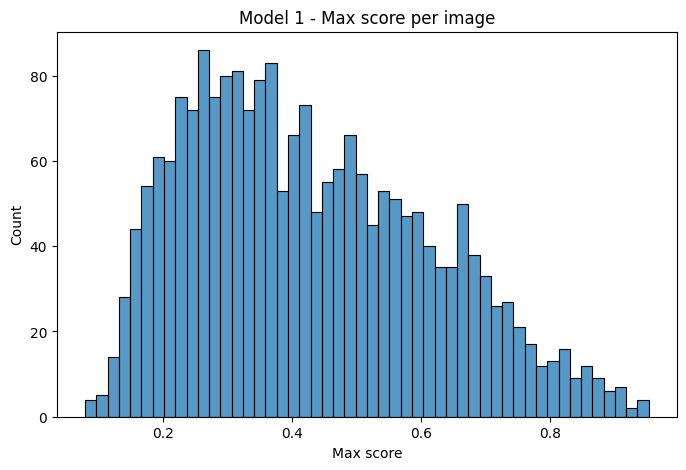

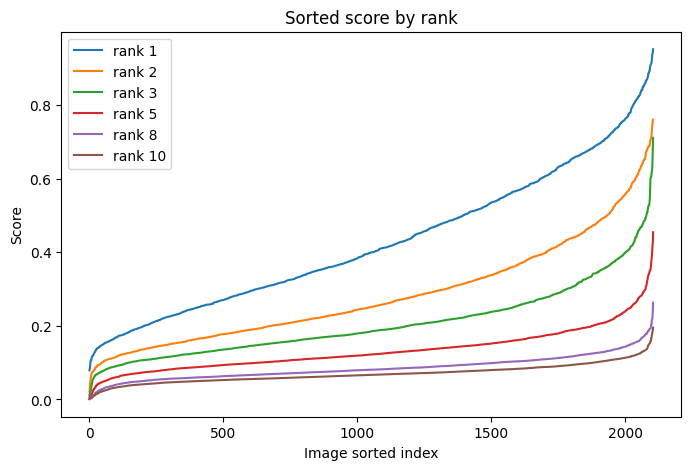

In [10]:
# ============================================================
# BLOQUE 7B — Visualización de distribución de scores
# ============================================================

plt.figure(figsize=(8, 5))
sns.histplot(max_score_original, bins=50)
plt.title("Model 1 - Max score per image")
plt.xlabel("Max score")
plt.ylabel("Count")
plt.show()

top_scores = np.sort(model1_image_scores, axis=1)[:, ::-1]

plt.figure(figsize=(8, 5))
for k in [1, 2, 3, 5, 8, 10]:
    plt.plot(np.arange(n_images), np.sort(top_scores[:, k - 1]), label=f"rank {k}")
plt.title("Sorted score by rank")
plt.xlabel("Image sorted index")
plt.ylabel("Score")
plt.legend()
plt.show()

# BLOQUE 8 — Funciones base para submissions

In [11]:
# ============================================================
# BLOQUE 8 — Funciones base para submissions
# ============================================================

def format_species_list(species_list):
    species_list = [str(x) for x in species_list]
    return "[" + ", ".join(species_list) + "]"


def prediction_length_from_string(pred_str):
    pred_str = str(pred_str).strip()
    
    if pred_str == "[]":
        return 0
    
    pred_str = pred_str.strip("[]")
    
    if pred_str == "":
        return 0
    
    return len([x for x in pred_str.split(",") if x.strip() != ""])


def fixed_topk_threshold_species(scores_row, species_values, topk, threshold):
    sorted_idx = np.argsort(scores_row)[::-1]
    
    selected = []
    
    for idx in sorted_idx:
        if len(selected) >= topk:
            break
        
        if scores_row[idx] >= threshold:
            selected.append(species_values[idx])
    
    # Safety fallback: Kaggle expects at least one predicted species
    if len(selected) == 0:
        selected = [species_values[sorted_idx[0]]]
    
    return selected


def create_fixed_submission(scores, quadrat_values, species_values, topk, threshold):
    rows = []
    
    for i in range(scores.shape[0]):
        selected_species = fixed_topk_threshold_species(
            scores_row=scores[i],
            species_values=species_values,
            topk=topk,
            threshold=threshold,
        )
        
        rows.append({
            "quadrat_id": quadrat_values[i],
            "species_ids": format_species_list(selected_species),
        })
    
    submission = pd.DataFrame(rows)
    return submission


def validate_submission(submission, expected_n_rows):
    assert list(submission.columns) == ["quadrat_id", "species_ids"]
    assert len(submission) == expected_n_rows
    assert submission["quadrat_id"].isna().sum() == 0
    assert submission["species_ids"].isna().sum() == 0
    assert submission["species_ids"].str.startswith("[").all()
    assert submission["species_ids"].str.endswith("]").all()
    
    return True


def save_submission(submission, output_path):
    validate_submission(submission, expected_n_rows=n_images)
    
    submission.to_csv(
        output_path,
        sep=",",
        index=False,
        quoting=csv.QUOTE_ALL,
    )
    
    mean_len = submission["species_ids"].apply(prediction_length_from_string).mean()
    
    return {
        "path": str(output_path),
        "mean_prediction_length": mean_len,
        "min_prediction_length": submission["species_ids"].apply(prediction_length_from_string).min(),
        "max_prediction_length": submission["species_ids"].apply(prediction_length_from_string).max(),
    }

# BLOQUE 9 — Generar blends alternativos max/mean

In [12]:
# ============================================================
# BLOQUE 9 — Generar blends alternativos max/mean
# ============================================================

score_matrices = {}

if CFG.use_original_score:
    score_matrices["original_saved_image_scores"] = model1_image_scores.astype(np.float32)

for blend_cfg in CFG.score_blends:
    name = blend_cfg["name"]
    max_w = blend_cfg["max_weight"]
    mean_w = blend_cfg["mean_weight"]
    
    blended_scores = (
        max_w * model1_max_scores +
        mean_w * model1_mean_scores
    ).astype(np.float32)
    
    score_matrices[name] = blended_scores
    
print("Available score matrices:")
for name, scores in score_matrices.items():
    print(name, scores.shape, scores.min(), scores.max(), scores.mean())

Available score matrices:
original_saved_image_scores (2105, 7806) 4.2410996e-08 0.9522273 0.0006656156
blend_max070_mean030 (2105, 7806) 4.2410996e-08 0.9522273 0.0006656156
blend_max060_mean040 (2105, 7806) 3.6679783e-08 0.94395286 0.0005888291
blend_max050_mean050 (2105, 7806) 3.0948566e-08 0.93567836 0.0005120423
blend_max040_mean060 (2105, 7806) 2.521735e-08 0.92740387 0.0004352551
max_only (2105, 7806) 5.9604645e-08 0.99316406 0.00089597807
mean_only (2105, 7806) 2.2924864e-09 0.8950571 0.00012810655


# BLOQUE 10 — Crear submissions fixed top-k/threshold

In [13]:
# ============================================================
# BLOQUE 10 — Crear submissions fixed top-k/threshold
# ============================================================

fixed_output_dir = CFG.submissions_dir / "fixed_topk_threshold"
fixed_output_dir.mkdir(parents=True, exist_ok=True)

submission_records = []

for score_name, scores in score_matrices.items():
    for sub_cfg in CFG.fixed_submission_configs:
        sub_name = sub_cfg["name"]
        topk = sub_cfg["topk"]
        threshold = sub_cfg["threshold"]
        
        submission = create_fixed_submission(
            scores=scores,
            quadrat_values=quadrat_values,
            species_values=species_values,
            topk=topk,
            threshold=threshold,
        )
        
        output_path = fixed_output_dir / f"submission_{score_name}_{sub_name}.csv"
        
        stats = save_submission(submission, output_path)
        
        submission_records.append({
            "type": "fixed",
            "score_name": score_name,
            "submission_name": sub_name,
            "topk": topk,
            "threshold": threshold,
            "path": stats["path"],
            "mean_prediction_length": stats["mean_prediction_length"],
            "min_prediction_length": stats["min_prediction_length"],
            "max_prediction_length": stats["max_prediction_length"],
        })

submission_summary = pd.DataFrame(submission_records)

display(submission_summary.head())
display(submission_summary.sort_values("mean_prediction_length").head(20))
display(submission_summary.sort_values("mean_prediction_length").tail(20))

,type,score_name,submission_name,topk,threshold,path,mean_prediction_length,min_prediction_length,max_prediction_length
0,fixed,original_saved_image_scores,top1_thr000,1,0.0,/kaggle/working/postprocessing_to_keep/submiss...,1.0,1,1
1,fixed,original_saved_image_scores,top2_thr000,2,0.0,/kaggle/working/postprocessing_to_keep/submiss...,2.0,2,2
2,fixed,original_saved_image_scores,top3_thr000,3,0.0,/kaggle/working/postprocessing_to_keep/submiss...,3.0,3,3
3,fixed,original_saved_image_scores,top4_thr000,4,0.0,/kaggle/working/postprocessing_to_keep/submiss...,4.0,4,4
4,fixed,original_saved_image_scores,top5_thr000,5,0.0,/kaggle/working/postprocessing_to_keep/submiss...,5.0,5,5


,type,score_name,submission_name,topk,threshold,path,mean_prediction_length,min_prediction_length,max_prediction_length
0,fixed,original_saved_image_scores,top1_thr000,1,0.00,/kaggle/working/postprocessing_to_keep/submiss...,1.000000,1,1
18,fixed,blend_max070_mean030,top1_thr000,1,0.00,/kaggle/working/postprocessing_to_keep/submiss...,1.000000,1,1
54,fixed,blend_max050_mean050,top1_thr000,1,0.00,/kaggle/working/postprocessing_to_keep/submiss...,1.000000,1,1
36,fixed,blend_max060_mean040,top1_thr000,1,0.00,/kaggle/working/postprocessing_to_keep/submiss...,1.000000,1,1
90,fixed,max_only,top1_thr000,1,0.00,/kaggle/working/postprocessing_to_keep/submiss...,1.000000,1,1
108,fixed,mean_only,top1_thr000,1,0.00,/kaggle/working/postprocessing_to_keep/submiss...,1.000000,1,1
72,fixed,blend_max040_mean060,top1_thr000,1,0.00,/kaggle/working/postprocessing_to_keep/submiss...,1.000000,1,1
120,fixed,mean_only,top5_thr005,5,0.05,/kaggle/working/postprocessing_to_keep/submiss...,1.443230,1,5
125,fixed,mean_only,top8_thr005,8,0.05,/kaggle/working/postprocessing_to_keep/submiss...,1.443230,1,5
123,fixed,mean_only,top6_thr005,6,0.05,/kaggle/working/postprocessing_to_keep/submiss...,1.443230,1,5


,type,score_name,submission_name,topk,threshold,path,mean_prediction_length,min_prediction_length,max_prediction_length
32,fixed,blend_max070_mean030,top6_thr004,6,0.04,/kaggle/working/postprocessing_to_keep/submiss...,5.952019,1,6
67,fixed,blend_max050_mean050,top6_thr003,6,0.03,/kaggle/working/postprocessing_to_keep/submiss...,5.952494,1,6
105,fixed,max_only,top6_thr005,6,0.05,/kaggle/working/postprocessing_to_keep/submiss...,5.959145,1,6
49,fixed,blend_max060_mean040,top6_thr003,6,0.03,/kaggle/working/postprocessing_to_keep/submiss...,5.962945,1,6
13,fixed,original_saved_image_scores,top6_thr003,6,0.03,/kaggle/working/postprocessing_to_keep/submiss...,5.969121,1,6
31,fixed,blend_max070_mean030,top6_thr003,6,0.03,/kaggle/working/postprocessing_to_keep/submiss...,5.969121,1,6
104,fixed,max_only,top6_thr004,6,0.04,/kaggle/working/postprocessing_to_keep/submiss...,5.969596,1,6
103,fixed,max_only,top6_thr003,6,0.03,/kaggle/working/postprocessing_to_keep/submiss...,5.978147,2,6
89,fixed,blend_max040_mean060,top8_thr005,8,0.05,/kaggle/working/postprocessing_to_keep/submiss...,6.801425,1,8
71,fixed,blend_max050_mean050,top8_thr005,8,0.05,/kaggle/working/postprocessing_to_keep/submiss...,7.351069,1,8


# BLOQUE 11 — Dynamic top-k por gaps y thresholds

In [14]:
# ============================================================
# BLOQUE 11 — Dynamic top-k por gaps y thresholds
# ============================================================

def dynamic_species_selection(
    scores_row,
    species_values,
    max_topk=8,
    min_topk=1,
    score_threshold=0.0,
    gap_threshold=None,
):
    sorted_idx = np.argsort(scores_row)[::-1]
    sorted_scores = scores_row[sorted_idx]
    
    selected = []
    
    for rank in range(max_topk):
        idx = sorted_idx[rank]
        score = sorted_scores[rank]
        
        if score < score_threshold:
            break
        
        selected.append(species_values[idx])
        
        if gap_threshold is not None and rank + 1 < max_topk:
            current_score = sorted_scores[rank]
            next_score = sorted_scores[rank + 1]
            
            if current_score <= 0:
                continue
            
            relative_gap = (current_score - next_score) / max(current_score, 1e-8)
            
            if rank + 1 >= min_topk and relative_gap >= gap_threshold:
                break
    
    if len(selected) < min_topk:
        selected = [species_values[idx] for idx in sorted_idx[:min_topk]]
    
    if len(selected) == 0:
        selected = [species_values[sorted_idx[0]]]
    
    return selected


def create_dynamic_submission(
    scores,
    quadrat_values,
    species_values,
    max_topk,
    min_topk,
    score_threshold,
    gap_threshold,
):
    rows = []
    
    for i in range(scores.shape[0]):
        selected_species = dynamic_species_selection(
            scores_row=scores[i],
            species_values=species_values,
            max_topk=max_topk,
            min_topk=min_topk,
            score_threshold=score_threshold,
            gap_threshold=gap_threshold,
        )
        
        rows.append({
            "quadrat_id": quadrat_values[i],
            "species_ids": format_species_list(selected_species),
        })
    
    submission = pd.DataFrame(rows)
    return submission

# BLOQUE 12 — Generar submissions dynamic top-k

In [15]:
# ============================================================
# BLOQUE 12 — Generar submissions dynamic top-k
# ============================================================

dynamic_output_dir = CFG.submissions_dir / "dynamic_topk"
dynamic_output_dir.mkdir(parents=True, exist_ok=True)

dynamic_records = []

for score_name, scores in score_matrices.items():
    for dyn_cfg in CFG.dynamic_configs:
        dyn_name = dyn_cfg["name"]
        
        submission = create_dynamic_submission(
            scores=scores,
            quadrat_values=quadrat_values,
            species_values=species_values,
            max_topk=dyn_cfg["max_topk"],
            min_topk=dyn_cfg["min_topk"],
            score_threshold=dyn_cfg["score_threshold"],
            gap_threshold=dyn_cfg["gap_threshold"],
        )
        
        output_path = dynamic_output_dir / f"submission_{score_name}_{dyn_name}.csv"
        
        stats = save_submission(submission, output_path)
        
        dynamic_records.append({
            "type": "dynamic",
            "score_name": score_name,
            "submission_name": dyn_name,
            "max_topk": dyn_cfg["max_topk"],
            "min_topk": dyn_cfg["min_topk"],
            "score_threshold": dyn_cfg["score_threshold"],
            "gap_threshold": dyn_cfg["gap_threshold"],
            "path": stats["path"],
            "mean_prediction_length": stats["mean_prediction_length"],
            "min_prediction_length": stats["min_prediction_length"],
            "max_prediction_length": stats["max_prediction_length"],
        })

dynamic_summary = pd.DataFrame(dynamic_records)

display(dynamic_summary.head())
display(dynamic_summary.sort_values("mean_prediction_length"))

,type,score_name,submission_name,max_topk,min_topk,score_threshold,gap_threshold,path,mean_prediction_length,min_prediction_length,max_prediction_length
0,dynamic,original_saved_image_scores,dynamic_gap_top8,8,1,0.00,0.15,/kaggle/working/postprocessing_to_keep/submiss...,1.504988,1,8
1,dynamic,original_saved_image_scores,dynamic_gap_top6,6,1,0.00,0.15,/kaggle/working/postprocessing_to_keep/submiss...,1.488361,1,6
2,dynamic,original_saved_image_scores,dynamic_gap_top5,5,1,0.00,0.12,/kaggle/working/postprocessing_to_keep/submiss...,1.353444,1,5
3,dynamic,original_saved_image_scores,dynamic_score_top8_thr003,8,1,0.03,NaN,/kaggle/working/postprocessing_to_keep/submiss...,7.924466,1,8
4,dynamic,original_saved_image_scores,dynamic_score_top6_thr003,6,1,0.03,NaN,/kaggle/working/postprocessing_to_keep/submiss...,5.969121,1,6


,type,score_name,submission_name,max_topk,min_topk,score_threshold,gap_threshold,path,mean_prediction_length,min_prediction_length,max_prediction_length
38,dynamic,mean_only,dynamic_gap_top5,5,1,0.00,0.12,/kaggle/working/postprocessing_to_keep/submiss...,1.265083,1,5
26,dynamic,blend_max040_mean060,dynamic_gap_top5,5,1,0.00,0.12,/kaggle/working/postprocessing_to_keep/submiss...,1.314014,1,5
20,dynamic,blend_max050_mean050,dynamic_gap_top5,5,1,0.00,0.12,/kaggle/working/postprocessing_to_keep/submiss...,1.328266,1,5
14,dynamic,blend_max060_mean040,dynamic_gap_top5,5,1,0.00,0.12,/kaggle/working/postprocessing_to_keep/submiss...,1.345368,1,5
8,dynamic,blend_max070_mean030,dynamic_gap_top5,5,1,0.00,0.12,/kaggle/working/postprocessing_to_keep/submiss...,1.353444,1,5
2,dynamic,original_saved_image_scores,dynamic_gap_top5,5,1,0.00,0.12,/kaggle/working/postprocessing_to_keep/submiss...,1.353444,1,5
32,dynamic,max_only,dynamic_gap_top5,5,1,0.00,0.12,/kaggle/working/postprocessing_to_keep/submiss...,1.370071,1,5
37,dynamic,mean_only,dynamic_gap_top6,6,1,0.00,0.15,/kaggle/working/postprocessing_to_keep/submiss...,1.379097,1,6
36,dynamic,mean_only,dynamic_gap_top8,8,1,0.00,0.15,/kaggle/working/postprocessing_to_keep/submiss...,1.399050,1,8
25,dynamic,blend_max040_mean060,dynamic_gap_top6,6,1,0.00,0.15,/kaggle/working/postprocessing_to_keep/submiss...,1.458432,1,6


# BLOQUE 13 — Priors suaves por grupo

In [16]:
# ============================================================
# BLOQUE 13 — Priors suaves por grupo
# ============================================================

def apply_group_prior(
    scores,
    test_meta_ordered,
    group_col,
    topk_group=30,
    boost=0.05,
    penalty=0.00,
):
    """
    Applies a soft group prior.
    
    For each group, species that frequently appear among top-k predictions
    receive a small multiplicative boost.
    
    This is unsupervised and should be used carefully.
    """
    adjusted = scores.copy()
    
    top_indices_per_image = np.argsort(scores, axis=1)[:, -topk_group:]
    
    groups = test_meta_ordered[group_col].fillna("UNKNOWN").values
    
    for group in pd.Series(groups).unique():
        group_mask = groups == group
        group_indices = np.where(group_mask)[0]
        
        if len(group_indices) <= 1:
            continue
        
        group_top_indices = top_indices_per_image[group_indices].reshape(-1)
        counts = pd.Series(group_top_indices).value_counts()
        
        # Keep species appearing repeatedly within the group
        repeated_species_idx = counts[counts >= max(2, int(0.05 * len(group_indices)))].index.values
        
        if len(repeated_species_idx) > 0:
            adjusted[np.ix_(group_indices, repeated_species_idx)] *= (1.0 + boost)
    
    adjusted = np.clip(adjusted, 0, None)
    
    return adjusted.astype(np.float32)


group_prior_configs = [
    {
        "name": "groupprior_prefix2_boost003",
        "group_col": "id_prefix_2",
        "topk_group": 30,
        "boost": 0.03,
    },
    {
        "name": "groupprior_prefix2_boost005",
        "group_col": "id_prefix_2",
        "topk_group": 30,
        "boost": 0.05,
    },
    {
        "name": "groupprior_transect_boost003",
        "group_col": "transect_guess",
        "topk_group": 25,
        "boost": 0.03,
    },
]

group_prior_score_matrices = {}

base_for_group_prior = {
    "original_saved_image_scores": score_matrices["original_saved_image_scores"],
    "blend_max050_mean050": score_matrices["blend_max050_mean050"],
    "blend_max040_mean060": score_matrices["blend_max040_mean060"],
}

for base_name, base_scores in base_for_group_prior.items():
    for gp_cfg in group_prior_configs:
        gp_name = f"{base_name}_{gp_cfg['name']}"
        
        adjusted_scores = apply_group_prior(
            scores=base_scores,
            test_meta_ordered=test_meta_ordered,
            group_col=gp_cfg["group_col"],
            topk_group=gp_cfg["topk_group"],
            boost=gp_cfg["boost"],
        )
        
        group_prior_score_matrices[gp_name] = adjusted_scores

print("Group prior score matrices:")
for name, scores in group_prior_score_matrices.items():
    print(name, scores.shape, scores.min(), scores.max(), scores.mean())

Group prior score matrices:
original_saved_image_scores_groupprior_prefix2_boost003 (2105, 7806) 4.2410996e-08 0.9807941 0.00067524094
original_saved_image_scores_groupprior_prefix2_boost005 (2105, 7806) 4.2410996e-08 0.9998386 0.00068165705
original_saved_image_scores_groupprior_transect_boost003 (2105, 7806) 4.2410996e-08 0.9807941 0.0006743451
blend_max050_mean050_groupprior_prefix2_boost003 (2105, 7806) 3.0948566e-08 0.9637487 0.00051942887
blend_max050_mean050_groupprior_prefix2_boost005 (2105, 7806) 3.0948566e-08 0.9824622 0.0005243522
blend_max050_mean050_groupprior_transect_boost003 (2105, 7806) 3.0948566e-08 0.9637487 0.00051873585
blend_max040_mean060_groupprior_prefix2_boost003 (2105, 7806) 2.521735e-08 0.95522594 0.0004415335
blend_max040_mean060_groupprior_prefix2_boost005 (2105, 7806) 2.521735e-08 0.973774 0.0004457195
blend_max040_mean060_groupprior_transect_boost003 (2105, 7806) 2.521735e-08 0.95522594 0.00044091512


# BLOQUE 14 — Submissions con priors suaves por grupo

In [17]:
# ============================================================
# BLOQUE 14 — Submissions con priors suaves por grupo
# ============================================================

group_prior_output_dir = CFG.submissions_dir / "group_prior"
group_prior_output_dir.mkdir(parents=True, exist_ok=True)

group_prior_records = []

group_prior_submission_configs = [
    {"name": "top3_thr003", "topk": 3, "threshold": 0.03},
    {"name": "top4_thr003", "topk": 4, "threshold": 0.03},
    {"name": "top5_thr003", "topk": 5, "threshold": 0.03},
    {"name": "top5_thr004", "topk": 5, "threshold": 0.04},
    {"name": "top6_thr004", "topk": 6, "threshold": 0.04},
]

for score_name, scores in group_prior_score_matrices.items():
    for sub_cfg in group_prior_submission_configs:
        sub_name = sub_cfg["name"]
        topk = sub_cfg["topk"]
        threshold = sub_cfg["threshold"]
        
        submission = create_fixed_submission(
            scores=scores,
            quadrat_values=quadrat_values,
            species_values=species_values,
            topk=topk,
            threshold=threshold,
        )
        
        output_path = group_prior_output_dir / f"submission_{score_name}_{sub_name}.csv"
        
        stats = save_submission(submission, output_path)
        
        group_prior_records.append({
            "type": "group_prior",
            "score_name": score_name,
            "submission_name": sub_name,
            "topk": topk,
            "threshold": threshold,
            "path": stats["path"],
            "mean_prediction_length": stats["mean_prediction_length"],
            "min_prediction_length": stats["min_prediction_length"],
            "max_prediction_length": stats["max_prediction_length"],
        })

group_prior_summary = pd.DataFrame(group_prior_records)

display(group_prior_summary.sort_values("mean_prediction_length"))

,type,score_name,submission_name,topk,threshold,path,mean_prediction_length,min_prediction_length,max_prediction_length
40,group_prior,blend_max040_mean060_groupprior_transect_boost003,top3_thr003,3,0.03,/kaggle/working/postprocessing_to_keep/submiss...,2.993349,1,3
30,group_prior,blend_max040_mean060_groupprior_prefix2_boost003,top3_thr003,3,0.03,/kaggle/working/postprocessing_to_keep/submiss...,2.994299,1,3
35,group_prior,blend_max040_mean060_groupprior_prefix2_boost005,top3_thr003,3,0.03,/kaggle/working/postprocessing_to_keep/submiss...,2.994299,1,3
15,group_prior,blend_max050_mean050_groupprior_prefix2_boost003,top3_thr003,3,0.03,/kaggle/working/postprocessing_to_keep/submiss...,2.995249,1,3
20,group_prior,blend_max050_mean050_groupprior_prefix2_boost005,top3_thr003,3,0.03,/kaggle/working/postprocessing_to_keep/submiss...,2.995249,1,3
25,group_prior,blend_max050_mean050_groupprior_transect_boost003,top3_thr003,3,0.03,/kaggle/working/postprocessing_to_keep/submiss...,2.995249,1,3
10,group_prior,original_saved_image_scores_groupprior_transec...,top3_thr003,3,0.03,/kaggle/working/postprocessing_to_keep/submiss...,2.995724,1,3
0,group_prior,original_saved_image_scores_groupprior_prefix2...,top3_thr003,3,0.03,/kaggle/working/postprocessing_to_keep/submiss...,2.995724,1,3
5,group_prior,original_saved_image_scores_groupprior_prefix2...,top3_thr003,3,0.03,/kaggle/working/postprocessing_to_keep/submiss...,2.995724,1,3
41,group_prior,blend_max040_mean060_groupprior_transect_boost003,top4_thr003,4,0.03,/kaggle/working/postprocessing_to_keep/submiss...,3.983848,1,4


# BLOQUE 15 — Sección futura para cargar modelo 2

In [18]:
# ============================================================
# BLOQUE 15 — Sección futura para cargar modelo 2
# ============================================================

model2_available = False

if CFG.use_model2:
    model2_image_scores_path = CFG.model2_to_keep_dir / "image_scores.npy"
    model2_max_scores_path = CFG.model2_to_keep_dir / "max_scores.npy"
    model2_mean_scores_path = CFG.model2_to_keep_dir / "mean_scores.npy"
    model2_test_ids_path = CFG.model2_to_keep_dir / "test_ids.csv"
    model2_species_ids_path = CFG.model2_to_keep_dir / "species_ids_clean.csv"
    
    assert model2_image_scores_path.exists(), model2_image_scores_path
    assert model2_test_ids_path.exists(), model2_test_ids_path
    assert model2_species_ids_path.exists(), model2_species_ids_path
    
    model2_image_scores = np.load(model2_image_scores_path)
    model2_max_scores = np.load(model2_max_scores_path)
    model2_mean_scores = np.load(model2_mean_scores_path)
    
    model2_test_ids = pd.read_csv(model2_test_ids_path)
    model2_species_ids = pd.read_csv(model2_species_ids_path)
    
    model2_test_ids["quadrat_id"] = model2_test_ids["quadrat_id"].astype(str)
    model2_species_ids["species_id"] = model2_species_ids["species_id"].astype(str)
    
    assert model2_image_scores.shape == model1_image_scores.shape
    assert model2_test_ids["quadrat_id"].tolist() == test_ids["quadrat_id"].tolist()
    assert model2_species_ids["species_id"].tolist() == species_ids["species_id"].tolist()
    
    model2_available = True
    
    print("Model 2 loaded correctly.")
else:
    print("Model 2 loading skipped. Set CFG.use_model2 = True when model 2 scores exist.")

Model 2 loading skipped. Set CFG.use_model2 = True when model 2 scores exist.


# BLOQUE 16 — Sección futura para ensemble modelo 1 + modelo 2

In [19]:
# ============================================================
# BLOQUE 16 — Sección futura para ensemble modelo 1 + modelo 2
# ============================================================

ensemble_records = []

if model2_available:
    ensemble_output_dir = CFG.submissions_dir / "ensemble_model1_model2"
    ensemble_output_dir.mkdir(parents=True, exist_ok=True)
    
    for ens_cfg in CFG.ensemble_weights:
        ens_name = ens_cfg["name"]
        w1 = ens_cfg["w1"]
        w2 = ens_cfg["w2"]
        
        ensemble_scores = (
            w1 * model1_image_scores +
            w2 * model2_image_scores
        ).astype(np.float32)
        
        for sub_cfg in CFG.fixed_submission_configs:
            sub_name = sub_cfg["name"]
            topk = sub_cfg["topk"]
            threshold = sub_cfg["threshold"]
            
            submission = create_fixed_submission(
                scores=ensemble_scores,
                quadrat_values=quadrat_values,
                species_values=species_values,
                topk=topk,
                threshold=threshold,
            )
            
            output_path = ensemble_output_dir / f"submission_{ens_name}_{sub_name}.csv"
            
            stats = save_submission(submission, output_path)
            
            ensemble_records.append({
                "type": "ensemble",
                "score_name": ens_name,
                "submission_name": sub_name,
                "topk": topk,
                "threshold": threshold,
                "path": stats["path"],
                "mean_prediction_length": stats["mean_prediction_length"],
                "min_prediction_length": stats["min_prediction_length"],
                "max_prediction_length": stats["max_prediction_length"],
            })
    
    ensemble_summary = pd.DataFrame(ensemble_records)
    display(ensemble_summary.sort_values("mean_prediction_length"))
else:
    ensemble_summary = pd.DataFrame()
    print("Ensemble skipped because model2 is not available.")

Ensemble skipped because model2 is not available.


# BLOQUE 17 — Consolidar resumen de submissions generadas

In [20]:
# ============================================================
# BLOQUE 17 — Consolidar resumen de submissions generadas
# ============================================================

summary_frames = []

if "submission_summary" in globals() and len(submission_summary) > 0:
    summary_frames.append(submission_summary)

if "dynamic_summary" in globals() and len(dynamic_summary) > 0:
    summary_frames.append(dynamic_summary)

if "group_prior_summary" in globals() and len(group_prior_summary) > 0:
    summary_frames.append(group_prior_summary)

if "ensemble_summary" in globals() and len(ensemble_summary) > 0:
    summary_frames.append(ensemble_summary)

all_submissions_summary = pd.concat(summary_frames, ignore_index=True)

all_submissions_summary.to_csv(
    CFG.output_dir / "all_generated_submissions_summary.csv",
    index=False,
)

display(all_submissions_summary.sort_values("mean_prediction_length").head(30))
display(all_submissions_summary.sort_values("mean_prediction_length").tail(30))

print("Total submissions generated:", len(all_submissions_summary))
print("Saved:", CFG.output_dir / "all_generated_submissions_summary.csv")

,type,score_name,submission_name,topk,threshold,path,mean_prediction_length,min_prediction_length,max_prediction_length,max_topk,min_topk,score_threshold,gap_threshold
0,fixed,original_saved_image_scores,top1_thr000,1.0,0.00,/kaggle/working/postprocessing_to_keep/submiss...,1.000000,1,1,NaN,NaN,NaN,NaN
18,fixed,blend_max070_mean030,top1_thr000,1.0,0.00,/kaggle/working/postprocessing_to_keep/submiss...,1.000000,1,1,NaN,NaN,NaN,NaN
54,fixed,blend_max050_mean050,top1_thr000,1.0,0.00,/kaggle/working/postprocessing_to_keep/submiss...,1.000000,1,1,NaN,NaN,NaN,NaN
36,fixed,blend_max060_mean040,top1_thr000,1.0,0.00,/kaggle/working/postprocessing_to_keep/submiss...,1.000000,1,1,NaN,NaN,NaN,NaN
90,fixed,max_only,top1_thr000,1.0,0.00,/kaggle/working/postprocessing_to_keep/submiss...,1.000000,1,1,NaN,NaN,NaN,NaN
108,fixed,mean_only,top1_thr000,1.0,0.00,/kaggle/working/postprocessing_to_keep/submiss...,1.000000,1,1,NaN,NaN,NaN,NaN
72,fixed,blend_max040_mean060,top1_thr000,1.0,0.00,/kaggle/working/postprocessing_to_keep/submiss...,1.000000,1,1,NaN,NaN,NaN,NaN
164,dynamic,mean_only,dynamic_gap_top5,NaN,NaN,/kaggle/working/postprocessing_to_keep/submiss...,1.265083,1,5,5.0,1.0,0.0,0.12
152,dynamic,blend_max040_mean060,dynamic_gap_top5,NaN,NaN,/kaggle/working/postprocessing_to_keep/submiss...,1.314014,1,5,5.0,1.0,0.0,0.12
146,dynamic,blend_max050_mean050,dynamic_gap_top5,NaN,NaN,/kaggle/working/postprocessing_to_keep/submiss...,1.328266,1,5,5.0,1.0,0.0,0.12


,type,score_name,submission_name,topk,threshold,path,mean_prediction_length,min_prediction_length,max_prediction_length,max_topk,min_topk,score_threshold,gap_threshold
172,group_prior,original_saved_image_scores_groupprior_prefix2...,top6_thr004,6.0,0.04,/kaggle/working/postprocessing_to_keep/submiss...,5.955344,1,6,NaN,NaN,NaN,NaN
177,group_prior,original_saved_image_scores_groupprior_prefix2...,top6_thr004,6.0,0.04,/kaggle/working/postprocessing_to_keep/submiss...,5.955819,1,6,NaN,NaN,NaN,NaN
105,fixed,max_only,top6_thr005,6.0,0.05,/kaggle/working/postprocessing_to_keep/submiss...,5.959145,1,6,NaN,NaN,NaN,NaN
49,fixed,blend_max060_mean040,top6_thr003,6.0,0.03,/kaggle/working/postprocessing_to_keep/submiss...,5.962945,1,6,NaN,NaN,NaN,NaN
142,dynamic,blend_max060_mean040,dynamic_score_top6_thr003,NaN,NaN,/kaggle/working/postprocessing_to_keep/submiss...,5.962945,1,6,6.0,1.0,0.03,NaN
130,dynamic,original_saved_image_scores,dynamic_score_top6_thr003,NaN,NaN,/kaggle/working/postprocessing_to_keep/submiss...,5.969121,1,6,6.0,1.0,0.03,NaN
136,dynamic,blend_max070_mean030,dynamic_score_top6_thr003,NaN,NaN,/kaggle/working/postprocessing_to_keep/submiss...,5.969121,1,6,6.0,1.0,0.03,NaN
31,fixed,blend_max070_mean030,top6_thr003,6.0,0.03,/kaggle/working/postprocessing_to_keep/submiss...,5.969121,1,6,NaN,NaN,NaN,NaN
13,fixed,original_saved_image_scores,top6_thr003,6.0,0.03,/kaggle/working/postprocessing_to_keep/submiss...,5.969121,1,6,NaN,NaN,NaN,NaN
104,fixed,max_only,top6_thr004,6.0,0.04,/kaggle/working/postprocessing_to_keep/submiss...,5.969596,1,6,NaN,NaN,NaN,NaN


Total submissions generated: 213
Saved: /kaggle/working/postprocessing_to_keep/all_generated_submissions_summary.csv


# BLOQUE 18 — Recomendaciones iniciales para someter

In [21]:
# ============================================================
# BLOQUE 18 — Recomendaciones iniciales para someter
# ============================================================

recommended = all_submissions_summary.copy()

# Prioritize conservative prediction lengths around 3 to 6 species
recommended = recommended[
    (recommended["mean_prediction_length"] >= 2.0) &
    (recommended["mean_prediction_length"] <= 6.5)
].copy()

recommended = recommended.sort_values(
    ["mean_prediction_length", "type", "score_name"],
    ascending=[True, True, True]
)

display(recommended.head(40))

print("Suggested first candidates to submit manually:")
for p in recommended.head(10)["path"].tolist():
    print(p)

,type,score_name,submission_name,topk,threshold,path,mean_prediction_length,min_prediction_length,max_prediction_length,max_topk,min_topk,score_threshold,gap_threshold
73,fixed,blend_max040_mean060,top2_thr000,2.0,0.00,/kaggle/working/postprocessing_to_keep/submiss...,2.000000,2,2,NaN,NaN,NaN,NaN
55,fixed,blend_max050_mean050,top2_thr000,2.0,0.00,/kaggle/working/postprocessing_to_keep/submiss...,2.000000,2,2,NaN,NaN,NaN,NaN
37,fixed,blend_max060_mean040,top2_thr000,2.0,0.00,/kaggle/working/postprocessing_to_keep/submiss...,2.000000,2,2,NaN,NaN,NaN,NaN
19,fixed,blend_max070_mean030,top2_thr000,2.0,0.00,/kaggle/working/postprocessing_to_keep/submiss...,2.000000,2,2,NaN,NaN,NaN,NaN
91,fixed,max_only,top2_thr000,2.0,0.00,/kaggle/working/postprocessing_to_keep/submiss...,2.000000,2,2,NaN,NaN,NaN,NaN
109,fixed,mean_only,top2_thr000,2.0,0.00,/kaggle/working/postprocessing_to_keep/submiss...,2.000000,2,2,NaN,NaN,NaN,NaN
1,fixed,original_saved_image_scores,top2_thr000,2.0,0.00,/kaggle/working/postprocessing_to_keep/submiss...,2.000000,2,2,NaN,NaN,NaN,NaN
114,fixed,mean_only,top3_thr003,3.0,0.03,/kaggle/working/postprocessing_to_keep/submiss...,2.138717,1,3,NaN,NaN,NaN,NaN
116,fixed,mean_only,top4_thr003,4.0,0.03,/kaggle/working/postprocessing_to_keep/submiss...,2.320665,1,4,NaN,NaN,NaN,NaN
118,fixed,mean_only,top5_thr003,5.0,0.03,/kaggle/working/postprocessing_to_keep/submiss...,2.387648,1,5,NaN,NaN,NaN,NaN


Suggested first candidates to submit manually:
/kaggle/working/postprocessing_to_keep/submissions/fixed_topk_threshold/submission_blend_max040_mean060_top2_thr000.csv
/kaggle/working/postprocessing_to_keep/submissions/fixed_topk_threshold/submission_blend_max050_mean050_top2_thr000.csv
/kaggle/working/postprocessing_to_keep/submissions/fixed_topk_threshold/submission_blend_max060_mean040_top2_thr000.csv
/kaggle/working/postprocessing_to_keep/submissions/fixed_topk_threshold/submission_blend_max070_mean030_top2_thr000.csv
/kaggle/working/postprocessing_to_keep/submissions/fixed_topk_threshold/submission_max_only_top2_thr000.csv
/kaggle/working/postprocessing_to_keep/submissions/fixed_topk_threshold/submission_mean_only_top2_thr000.csv
/kaggle/working/postprocessing_to_keep/submissions/fixed_topk_threshold/submission_original_saved_image_scores_top2_thr000.csv
/kaggle/working/postprocessing_to_keep/submissions/fixed_topk_threshold/submission_mean_only_top3_thr003.csv
/kaggle/working/post

# BLOQUE 19 — Validar una submission específica antes de descargar/someter

In [22]:
# ============================================================
# BLOQUE 19 — Validar una submission específica antes de descargar/someter
# ============================================================

selected_submission_path = recommended.iloc[0]["path"]

selected_submission = pd.read_csv(selected_submission_path)

validate_submission(selected_submission, expected_n_rows=n_images)

display(selected_submission.head())
display(selected_submission["species_ids"].apply(prediction_length_from_string).describe())

print("Selected submission:")
print(selected_submission_path)

,quadrat_id,species_ids
0,CBN-PdlC-E3-20130723,"[1722440, 1396253]"
1,CBN-PdlC-E2-20130723,"[1392407, 1397528]"
2,CBN-PdlC-E5-20130723,"[1390793, 1393200]"
3,CBN-PdlC-E6-20130723,"[1392565, 1397535]"
4,CBN-PdlC-E1-20130723,"[1390793, 1392565]"


count    2105.0
mean        2.0
std         0.0
min         2.0
25%         2.0
50%         2.0
75%         2.0
max         2.0
Name: species_ids, dtype: float64

Selected submission:
/kaggle/working/postprocessing_to_keep/submissions/fixed_topk_threshold/submission_blend_max040_mean060_top2_thr000.csv


# BLOQUE 20 — Resumen final de archivos generados

In [23]:
# ============================================================
# BLOQUE 20 — Resumen final de archivos generados
# ============================================================

print("Files generated in postprocessing output:")

for p in sorted(CFG.output_dir.rglob("*")):
    if p.is_file():
        size_mb = p.stat().st_size / (1024 ** 2)
        print(f"{size_mb:8.2f} MB | {p}")

Files generated in postprocessing output:
    0.04 MB | /kaggle/working/postprocessing_to_keep/all_generated_submissions_summary.csv
    0.08 MB | /kaggle/working/postprocessing_to_keep/submissions/dynamic_topk/submission_blend_max040_mean060_dynamic_gap_top5.csv
    0.08 MB | /kaggle/working/postprocessing_to_keep/submissions/dynamic_topk/submission_blend_max040_mean060_dynamic_gap_top6.csv
    0.08 MB | /kaggle/working/postprocessing_to_keep/submissions/dynamic_topk/submission_blend_max040_mean060_dynamic_gap_top8.csv
    0.14 MB | /kaggle/working/postprocessing_to_keep/submissions/dynamic_topk/submission_blend_max040_mean060_dynamic_score_top5_thr004.csv
    0.16 MB | /kaggle/working/postprocessing_to_keep/submissions/dynamic_topk/submission_blend_max040_mean060_dynamic_score_top6_thr003.csv
    0.20 MB | /kaggle/working/postprocessing_to_keep/submissions/dynamic_topk/submission_blend_max040_mean060_dynamic_score_top8_thr003.csv
    0.08 MB | /kaggle/working/postprocessing_to_keep/s